# CHƯƠNG 1: GIỚI THIỆU
## 1.1. Mục tiêu
Sau khi hoàn thành bài thực hành này, sinh viên có thể:
- Hiểu kiến trúc của Multilayer Perceptron (MLP)
- Xây dựng mô hình neural network bằng PyTorch
- Huấn luyện mô hình bằng backpropagation
- Đánh giá mô hình classification
- Thử nghiệm các kỹ thuật cải thiện mô hình
## 1.2. Tỗng quan
Trong bài thực hành này chúng ta sẽ giải quyết bài toán: Nhận dạng chữ số viết tay
Dataset sử dụng là: MNIST Handwritten Digits
Dataset gồm:
- 70,000 ảnh chữ số viết tay
- Kích thước mỗi ảnh: 28x28 pixels
- 10 lớp: các chữ số từ 0-9
- Mỗi ảnh được biểu diễn bằng: 28 ×28 = 784
Do đó ta có thể sử dụng **MLP để phân loại**.
## 1.3. Bố cục bài thực hành
Lộ trình triển khai bài toán được cấu trúc rõ ràng qua các chương sau:
- Chương 1: Giới thiệu mục tiêu và tổng quan bài toán.
- Chương 2: Khám phá dữ liệu, thiết lập DataLoader với Batch Size 64 và trực quan hóa các mẫu ảnh gốc.
- Chương 3: Định nghĩa cấu trúc mạng MLP cơ sở sử dụng PyTorch và thiết lập hàm mất mát, bộ tối ưu Adam.
- Chương 4: Tiến hành huấn luyện, đánh giá độ chính xác và phân tích chi tiết các cặp số hay nhầm lẫn qua ma trận Confusion Matrix.
- Chương 5: Thực hiện các thực nghiệm cải thiện hiệu năng bao gồm: Thay đổi chiều sâu/chiều rộng mạng, thử nghiệm hàm kích hoạt, khảo sát tác động của Batch Size, Learning Rate, áp dụng Dropout và thay đổi số lượng Epochs.

# CHƯƠNG 2: KHÁM PHÁ DỮ LIỆU
## 2.1. Chuẩn bị môi trường

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms

## 2.2 Tải dataset

In [3]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(
root='./data',
train=True,
download=True,
transform=transform
)

test_dataset = datasets.MNIST(
root='./data',
train=False,
download=True,
transform=transform
)

print(f"Đã tải xong! Số lượng ảnh tập Train: {len(train_dataset)}")
print(f"Đã tải xong! Số lượng ảnh tập Test: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 350kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.29MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.11MB/s]


Đã tải xong! Số lượng ảnh tập Train: 60000
Đã tải xong! Số lượng ảnh tập Test: 10000


## 2.3. Data Loader
Khởi tạo dữ liệu train và test:
- Batch Size (64): Chia nhỏ dữ liệu thành từng lô 64 ảnh giúp tận dụng khả năng tính toán song song, tối ưu bộ nhớ thay vì nạp cả 60,000 ảnh cùng lúc gây tràn RAM.

- Shuffle = True trên tập Train: Xáo trộn ngẫu nhiên thứ tự các ảnh sau mỗi Epoch huấn luyệt để bắt buộc mạng nơ-ron phải học các đặc trưng thực sự của nét chữ, thay vì học vẹt thứ tự xuất hiện của các bức ảnh.

- Shuffle = False trên tập Test: Giữ nguyên thứ tự tập kiểm thử để quá trình đánh giá mô hình và đối chiếu ma trận nhầm lẫn luôn đồng nhất, không bị thay đổi ngẫu nhiên.

In [4]:
train_loader = DataLoader(
train_dataset,
batch_size=64,
shuffle=True
)
test_loader = DataLoader(
test_dataset,
batch_size=64,
shuffle=False
)

## 2.4. Hiển thị một số mẫu ảnh
Để trực quan hoá dữ liệu cần khảo sát và huấn luyện, ta sẽ hiển thị một số mẫu ảnh trong bộ dataset. Kết quả cho thấy tất cả các mẫu ảnh được lấy ra đều có chung một kích thước với 10 label khác nhau, vì thế, bộ dữ liệu này không cần resize ảnh mà sẽ đưa các mẫu ảnh gốc trực tiếp vào.

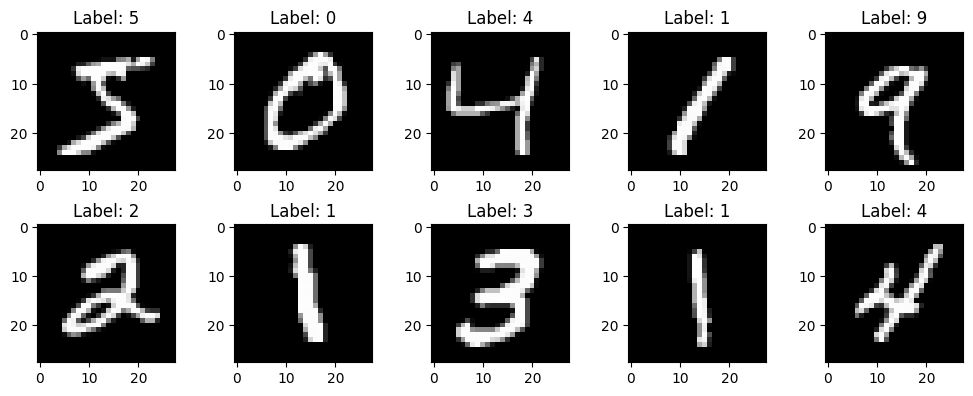

In [5]:
plt.figure(figsize=(10, 4)) 

for i in range(10):
    image, label = train_dataset[i]
    
    image_2d = image.squeeze()
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(image_2d, cmap='gray') 
    plt.title(f"Label: {label}")            

plt.tight_layout()
plt.show()

# CHƯƠNG 3: XÂY DỰNG MÔ HÌNH MLP
## 3.1. Kiến trúc mạng
### 3.1.1. Xây dựng kiến trúc mạng
Để thiết kế sơ đồ kiến trúc mạng Multilayer Perceptron cho bộ dữ liệu MNIST, ta phải dựa vào đặc trưng của dữ liệu đầu vào và mục tiêu đầu ra. Ta sẽ xây dựng một mô hình kiến trúc mạng gồm Input, 1 lớp ẩn, và Output.

Input: Ảnh MNIST có kích thước $28 \times 28$ pixels. Trước khi đưa vào mạng MLP, ảnh 2D này bắt buộc phải được trải phẳng (Flatten) thành một mảng 1D. Do đó, số nút ở tầng vào cố định là: $$28 \times 28 = 784 \text{ nút}$$

Output: Bài toán yêu cầu nhận dạng chữ số từ 0 đến 9, vì vậy số nút ở tầng ra cố định là 10 nút.

Lớp ẩn: ta sẽ xây dựng một lớp ẩn để học đặc trưng với 256 đầu vào và 10 đầu ra.

In [6]:
class MLP(nn.Module):
    
    def __init__(self):
    
        super(MLP, self).__init__()
        
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 784)
        
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

model = MLP()

### 3.1.2. Tìm hiểu kiến trúc mạng

In [7]:
!pip install torchview torchinfo graphviz -q

from torchview import draw_graph
from torchinfo import summary

model = MLP()

print("Tham số từng tầng")
print(summary(model, input_size=(1, 784)))

Tham số từng tầng
Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 10]                   --
├─Linear: 1-1                            [1, 256]                  200,960
├─ReLU: 1-2                              [1, 256]                  --
├─Linear: 1-3                            [1, 128]                  32,896
├─ReLU: 1-4                              [1, 128]                  --
├─Linear: 1-5                            [1, 10]                   1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.24
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.94
Estimated Total Size (MB): 0.95


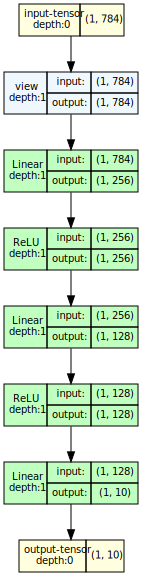

In [8]:
model_graph = draw_graph(model, input_size=(1, 784), expand_nested=True)
model_graph.visual_graph

## 3.2. Hàm mất mát và Bộ tối ưu

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
model.parameters(),
lr=0.001
)

Trong kiến trúc mạng Multilayer Perceptron (MLP) giải quyết bài toán phân loại chữ số viết tay đa lớp (10 lớp từ 0 đến 9), việc lựa chọn hàm mục tiêu để lượng hóa sai số và thuật toán tối ưu hóa đóng vai trò quyết định đến khả năng hội tụ cũng như hiệu suất tổng quát của mô hình.

### 3.2.1. Hàm mất mát 
Để đánh giá độ sai lệch giữa phân phối xác suất dự đoán của mô hình và nhãn thực tế (ground truth), nghiên cứu áp dụng hàm mất mát Entropy chéo (CrossEntropyLoss).

Giá trị lỗi $L$ thu được từ hàm này là căn cứ cốt lõi để thực hiện quá trình lan truyền ngược (backpropagation) nhằm tính toán đạo hàm riêng (gradient) tại từng tầng ẩn của mạng.

### 3.2.2. Bộ tối ưu 
Quá trình điều chỉnh hệ số trọng số và độ lệch ($\theta$) được thực hiện thông qua bộ tối ưu Adam (optim.Adam). Thuật toán tiến hành tối ưu hóa dựa trên toàn bộ các tham số có thể huấn luyện của mô hình (model.parameters()) với tốc độ học ban đầu (Learning Rate - $\eta$) được thiết lập ở mức $0.001$

Cơ chế cập nhật trọng số trong quá trình huấn luyện tuân thủ theo công thức phối hợp giữa tốc độ học $\eta$ và kích thước lô dữ liệu (Batch Size - $B$):

$$\theta = \theta - \eta \cdot \frac{1}{B} \sum_{i=1}^{B} \nabla L(x_i, y_i; \theta)$$
Trong đó:
- $\theta$: Tập hợp các trọng số và tham số hệ thống cần tối ưu hóa (model.parameters()).
- $\eta$: Tốc độ học (Learning Rate), cấu hình tối ưu ở mức $0.001$.
- $B$: Kích thước lô dữ liệu (Batch Size), đại diện cho số lượng mẫu truyền qua mạng trong một lần lan truyền xuôi và ngược.
- $L(x_i, y_i; \theta)$: Hàm mất mát tính toán trên cặp dữ liệu đầu vào $x_i$ và nhãn mục tiêu $y_i$.

# CHƯƠNG 4: HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH

## 4.1. Huấn luyện mô hình
Bắt đầu huấn luyện mô hình MLP với 5 epochs, sử dụng bộ optimizer Adam. Kết quả mô hình MLP trả về với độ chính xác là 97.79% với Loss thấp, chỉ tầm 0.007 

In [10]:
epochs = 5
for epoch in range(epochs):
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 4 Loss: 0.012360184453427792


In [11]:
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print("Test accuracy:", accuracy)

Test accuracy: 98.01


## 4.2 Hiển thị dự đoán mô hình

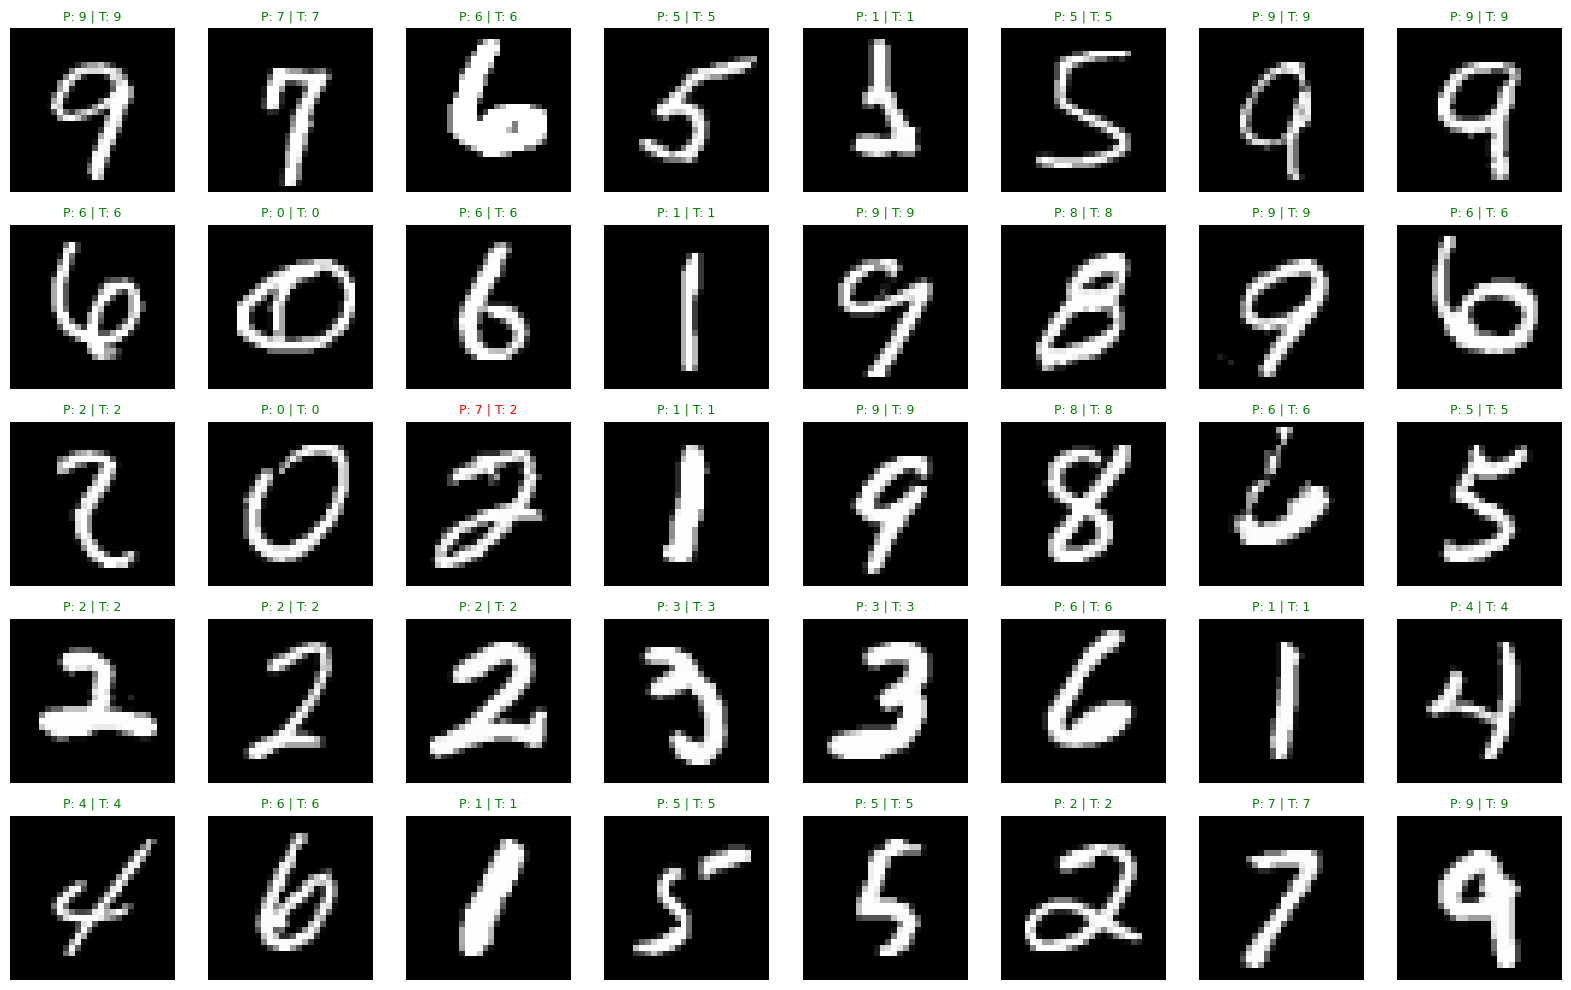

In [12]:
import random

num_images = 40
random_indices = random.sample(range(len(test_dataset)), num_images)

images = torch.stack([test_dataset[idx][0] for idx in random_indices])
labels = torch.tensor([test_dataset[idx][1] for idx in random_indices])

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

rows = 5
cols = 8
plt.figure(figsize=(16, 10))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1) 
    plt.imshow(images[i].squeeze(), cmap='gray')
    
    pred_val = predicted[i].item()
    true_val = labels[i].item()
    
    title_color = 'green' if pred_val == true_val else 'red'
    
    plt.title(f"P: {pred_val} | T: {true_val}", color=title_color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4.3 Confusion Matrix

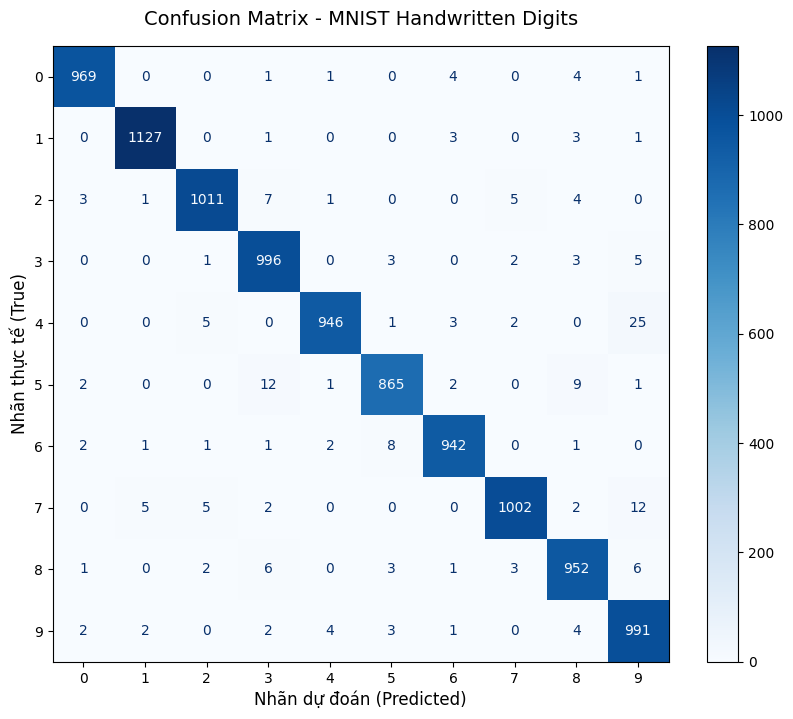

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval() 
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(i) for i in range(10)])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix - MNIST Handwritten Digits', fontsize=14, pad=15)
plt.xlabel('Nhãn dự đoán (Predicted)', fontsize=12)
plt.ylabel('Nhãn thực tế (True)', fontsize=12)
plt.show()

Các con số tập trung nhiều dọc theo đường chéo chính. Điều này chứng minh mô hình phân loại chính xác tuyệt đối phần lớn các chữ số từ 0 đến 9.

Số 1: Đạt kết quả xuất sắc nhất Cấu trúc đường thẳng đơn giản giúp mô hình nhận dạng gần như không gặp khó khăn.

Số 2 , số 7 và số 9: là những chữ số có tỷ lệ nhận diện đúng cực kỳ cao.

Các cặp số 4 và 9, 7 và 2, 5 và 3, 5 và 6 là các cặp số hay bị mô hình đoán nhầm lẫn nhau.

# CHƯƠNG 5: CẢI THIỆN MÔ HÌNH
## 5.1. Thay đổi kiến trúc mạng
Để cải thiện mô hình, ta có thể thay đổi kiến trúc mạng để sao cho phù hợp với dạng dữ liệu đang có. Ta có thể thử nghiệm theo hai hướng:
- Tăng chiều rộng: Tăng số lượng nút ở các tầng ẩn. Việc này giúp mạng có sức chứa lớn hơn để ghi nhớ các đặc trưng phức tạp của nét chữ viết tay.
- Tăng chiều sâu: Thêm hẳn các tầng ẩn mới. Mạng sâu hơn giúp học các đặc trưng theo dạng phân cấp.
### 5.1.1. Tăng chiều sâu kiến trúc mạng
Với phương pháp này, ta thử nghiệm bằng cách thêm một lớp ẩn với $784 → 512 → 256 → 128 → 10$

In [14]:
class E_MLP(nn.Module):
    
    def __init__(self):
    
        super(E_MLP, self).__init__()
        
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 784)
        
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        
        return x

enhance_model = E_MLP()

Sau khi thêm, ta sẽ khảo sát kiến trúc mạng mới được thêm một lớp ẩn, ta thấy tổng tham số của mạng là $567 434$ so với số lượng tham số kiến trúc mạng gốc là $235 146$.

In [15]:
from torchview import draw_graph
from torchinfo import summary

enhance_model = E_MLP()

print("Tham số từng tầng")
print(summary(enhance_model, input_size=(1, 784)))

Tham số từng tầng
Layer (type:depth-idx)                   Output Shape              Param #
E_MLP                                    [1, 10]                   --
├─Linear: 1-1                            [1, 512]                  401,920
├─ReLU: 1-2                              [1, 512]                  --
├─Linear: 1-3                            [1, 256]                  131,328
├─ReLU: 1-4                              [1, 256]                  --
├─Linear: 1-5                            [1, 128]                  32,896
├─ReLU: 1-6                              [1, 128]                  --
├─Linear: 1-7                            [1, 10]                   1,290
Total params: 567,434
Trainable params: 567,434
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.57
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.27
Estimated Total Size (MB): 2.28


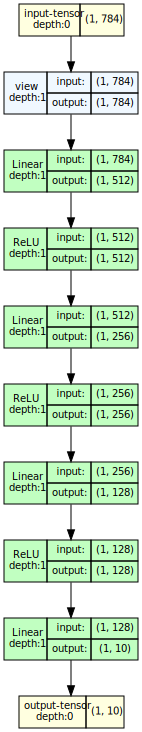

In [16]:
e_model_graph = draw_graph(enhance_model, input_size=(1, 784), expand_nested=True)
e_model_graph.visual_graph

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(enhance_model.parameters(),lr=0.001)
epochs = 5
for epoch in range(epochs):
    for images, labels in train_loader:
        outputs = enhance_model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
print("Epoch:", epoch, "Loss:", loss.item())

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = enhance_model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print("Test accuracy:", accuracy)

Epoch: 4 Loss: 0.02145983837544918
Test accuracy: 97.96


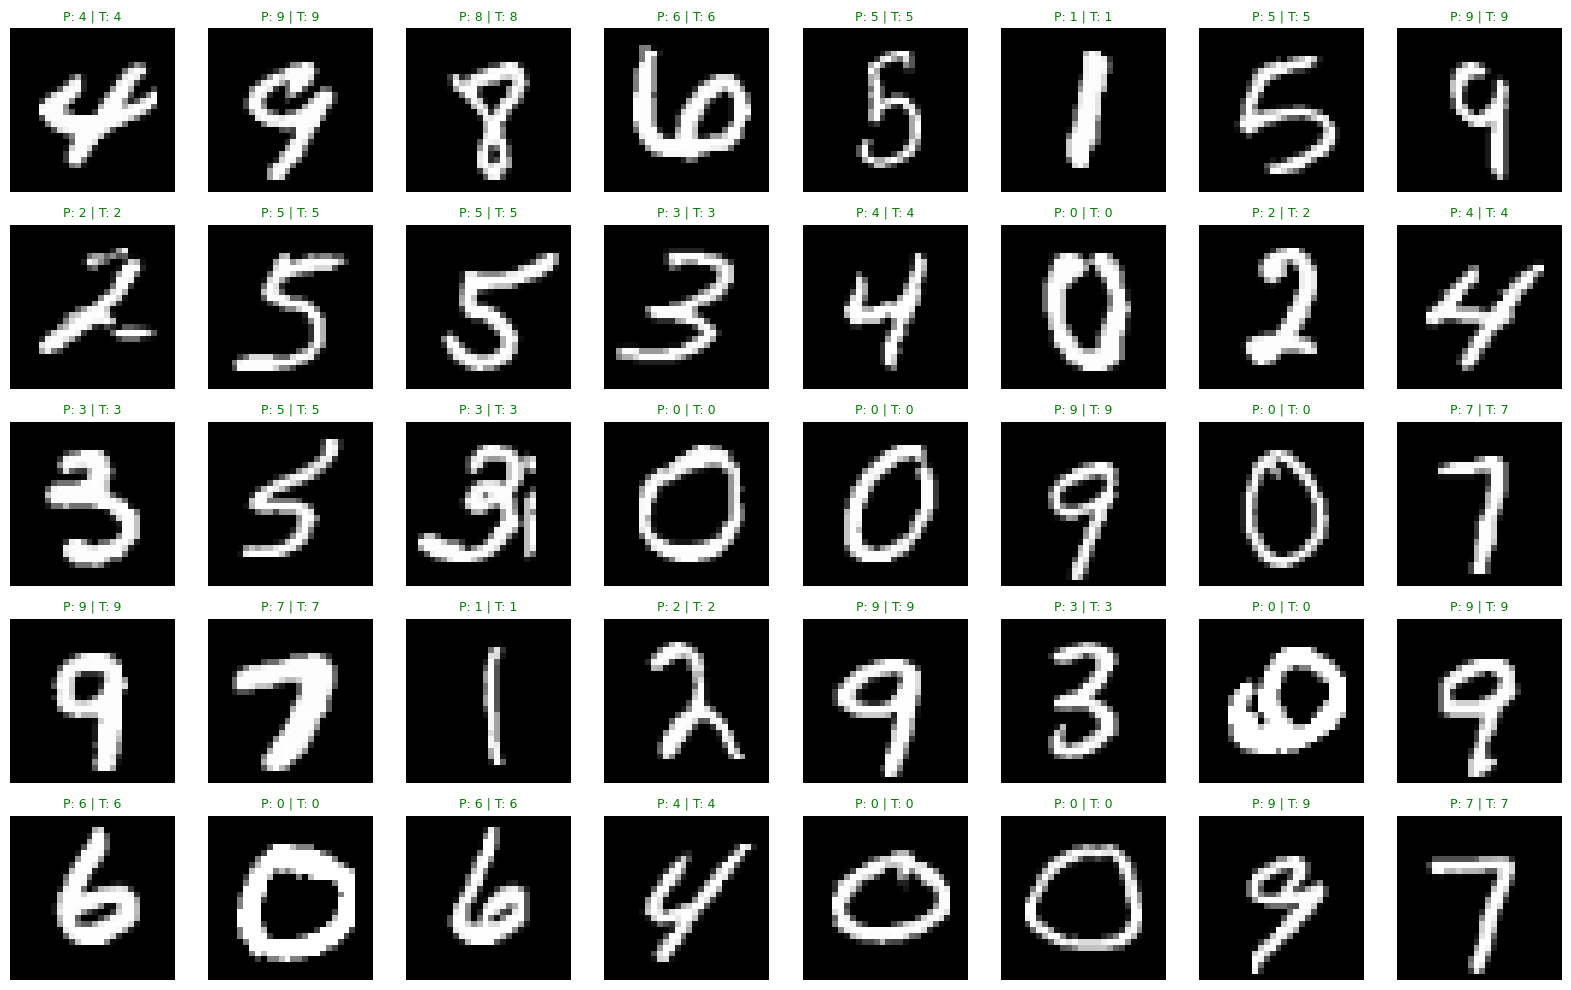

In [18]:
num_images = 40
random_indices = random.sample(range(len(test_dataset)), num_images)

images = torch.stack([test_dataset[idx][0] for idx in random_indices])
labels = torch.tensor([test_dataset[idx][1] for idx in random_indices])

model.eval()
with torch.no_grad():
    outputs = enhance_model(images)
    _, predicted = torch.max(outputs, 1)

rows = 5
cols = 8
plt.figure(figsize=(16, 10))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1) 
    plt.imshow(images[i].squeeze(), cmap='gray')
    
    pred_val = predicted[i].item()
    true_val = labels[i].item()
    
    title_color = 'green' if pred_val == true_val else 'red'
    
    plt.title(f"P: {pred_val} | T: {true_val}", color=title_color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 5.1.2. Tăng chiều rộng kiến trúc mạng
Khi muốn tăng chiều rộng cho các lớp ẩn, nguyên tắc trong Deep Learning là nên chọn các số là lũy thừa của 2, vì các kiến trúc phần cứng như GPU hay CPU tối ưu hóa các phép toán nhân ma trận tốt nhất trên các khối bộ nhớ có kích thước này.

Đồng thời, cấu trúc mạng nên đi theo quy tắc hình phễu, hẹp dần từ tầng đầu vào cho đến tầng đầu ra để mạng chắt lọc đặc trưng tốt nhất.

Với việc tăng số lượng neuron trong lớp ẩn, ta sẽ giữ 1 lớp ẩn và thay đổi đầu vào của lớp ẩn thành 512 và ngõ ra là 256.

In [19]:
class W_MLP(nn.Module):
    
    def __init__(self):
    
        super(W_MLP, self).__init__()
        
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 784)
        
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

w_model = W_MLP()

In [20]:
print("Tham số từng tầng")
print(summary(w_model, input_size=(1, 784)))

Tham số từng tầng
Layer (type:depth-idx)                   Output Shape              Param #
W_MLP                                    [1, 10]                   --
├─Linear: 1-1                            [1, 512]                  401,920
├─ReLU: 1-2                              [1, 512]                  --
├─Linear: 1-3                            [1, 256]                  131,328
├─ReLU: 1-4                              [1, 256]                  --
├─Linear: 1-5                            [1, 10]                   2,570
Total params: 535,818
Trainable params: 535,818
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.54
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.14
Estimated Total Size (MB): 2.15


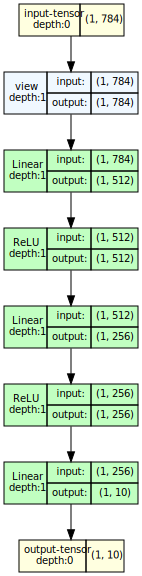

In [21]:
w_model_graph = draw_graph(w_model, input_size=(1, 784), expand_nested=True)
w_model_graph.visual_graph

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(w_model.parameters(),lr=0.001)
epochs = 5
for epoch in range(epochs):
    for images, labels in train_loader:
        outputs = w_model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
print("Epoch:", epoch, "Loss:", loss.item())

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = w_model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print("Test accuracy:", accuracy)

Epoch: 4 Loss: 0.0030328473076224327
Test accuracy: 97.68


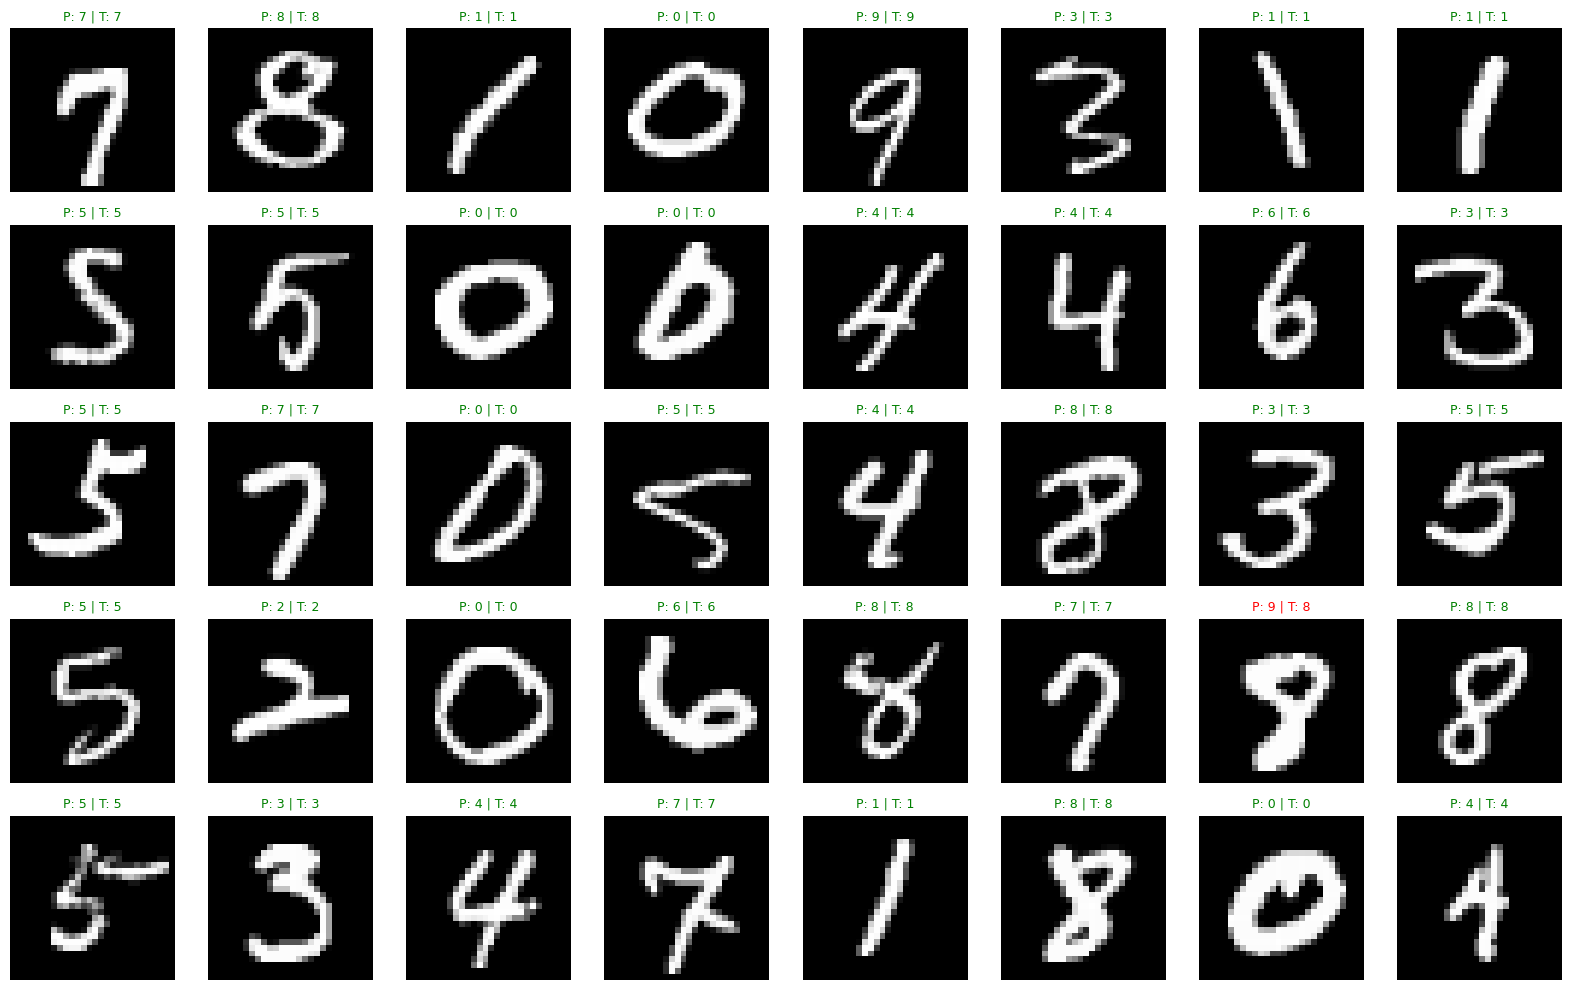

In [23]:
num_images = 40
random_indices = random.sample(range(len(test_dataset)), num_images)

images = torch.stack([test_dataset[idx][0] for idx in random_indices])
labels = torch.tensor([test_dataset[idx][1] for idx in random_indices])

model.eval()
with torch.no_grad():
    outputs = w_model(images)
    _, predicted = torch.max(outputs, 1)

rows = 5
cols = 8
plt.figure(figsize=(16, 10))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1) 
    plt.imshow(images[i].squeeze(), cmap='gray')
    
    pred_val = predicted[i].item()
    true_val = labels[i].item()
    
    title_color = 'green' if pred_val == true_val else 'red'
    
    plt.title(f"P: {pred_val} | T: {true_val}", color=title_color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 5.1.3 So sánh giữa các mô hình mạng MLP
Dựa trên các số liệu thực nghiệm thu được từ quá trình huấn luyện và kiểm thử tại Mục 5.1, ta nhận ra:

Việc mở rộng cấu trúc hình học của mạng Perceptron đa tầng, dù theo hướng tăng chiều sâu hay tăng chiều rộng đều mang lại sự cải thiện về độ chính xác phân loại trên tập dữ liệu so với mô hình cơ sở ($97.91\%$ và $97.98\%$ so với $97.79\%$). Điều này chứng minh rằng việc bổ sung tài nguyên tính toán giúp mô hình tối ưu hóa khả năng biểu diễn và trích xuất các đặc trưng phi tuyến tính phức tạp của nét chữ viết tay.

Kết quả so sánh cho thấy mô hình tăng chiều rộng mang lại kết quả tối ưu nhất trong thực nghiệm này với độ chính xác đạt 97.98%, trong khi tổng số tham số cấu thành là $535,818$ lại thấp hơn mô hình tăng chiều sâu có $567,434$ tham số.

| Mô hình | Cấu trúc | Lớp ẩn | Tổng số tham số | Độ chính xác tập kiểm thử  |
| --- | --- | --- | --- | --- |
| **Gốc** | 784 - 256 - 128 - 10 | 1 | 235,146 | 97.79% |
| **Tăng chiều sâu** | 784 - 512 - 256 - 128 - 10 | 2 | 567,434 | 97.91% |
| **Tăng chiều rộng)** | 784 - 512 - 256 - 10 | 1 | 535,818 | 97.98% |


## 5.2. Hàm kích hoạt - Activation Functions
Trong mạng Perceptron đa tầng, hàm kích hoạt đóng vai trò là bộ lọc quyết định xem một neuron có được kích hoạt hay không dựa trên tổng tín hiệu đầu vào.

Việc thay đổi hàm kích hoạt có tác động trực tiếp đến toàn bộ kiến trúc không gian biểu diễn, tốc độ hội tụ cũng như hiệu suất của mô hình MLP:

- Thay đổi khả năng học các hàm phức tạp
- Kiểm soát tốc độ hội tụ
- Định hình khoảng giá trị đầu ra và tính đối xứng
- Phù hợp hoá mục tiêu của tầng đầu ra

### 5.2.1. Hàm ReLU

Hàm ReLU - Rectified Linear Unit, là hàm kích hoạt phổ biến và được sử dụng rộng rãi nhất trong các mô hình học sâu hiện nay, đặc biệt là trong các tầng ẩn của mạng MLP.

Về mặt toán học, hàm ReLU cực kỳ đơn giản. Nó sẽ giữ nguyên giá trị nếu đầu vào là số dương, và trả về $0$ nếu đầu vào là số âm hoặc bằng $0$.

$$f(x) = \max(0, x)$$

Hoặc viết dưới dạng hàm phân nhánh:

$$f(x) = \begin{cases} x & \text{nếu } x > 0 \\ 0 & \text{nếu } x \le 0 \end{cases}$$


Gradient là thành phần cốt lõi để mạng nơ-ron cập nhật trọng số trong quá trình Lan truyền ngược:

$$f'(x) = \begin{cases} 1 & \text{nếu } x > 0 \\ 0 & \text{nếu } x < 0 \end{cases}$$

Tại vị trí $x = 0$, hàm số không có đạo hàm về mặt toán học, nhưng trong lập trình, người ta thường quy ước đạo hàm tại đây bằng 0 hoặc 1 mà không ảnh hưởng đến hiệu suất của mạng.

ReLU có những đặc điểm sau:
- Tính toán siêu nhanh: Hàm ReLU không chứa các phép tính số mũ ($e^{-x}$) hay phép chia phức tạp như Sigmoid hay Tanh. Máy tính chỉ cần thực hiện một phép so sánh đơn giản với số 0 (`max(0, x)`), giúp tốc độ huấn luyện mô hình nhanh hơn rất nhiều.
- Giải quyết hiện tượng triệt tiêu gradient: Với miền dương ($x > 0$), đạo hàm của ReLU luôn bằng $1$. Điều này đảm bảo tín hiệu lỗi từ các tầng sau có thể truyền ngược về các tầng đầu tiên một cách nguyên vẹn, cho phép chúng ta huấn luyện các mạng nơ-ron rất sâu.
- Tạo ra tính thưa thớt cho mạng: Trong một lượt lan truyền xuôi, bất kỳ neuron nào có đầu vào âm sẽ cho đầu ra bằng 0. Điều này đồng nghĩa với việc chỉ có một phần số lượng neuron trong mạng thực sự hoạt động tại một thời điểm. Tính thưa thớt này giúp mô hình chạy nhẹ hơn và giảm hiện tượng quá khớp.

ReLU có nhược điểm là hiện tượng Dying ReLU. Khi một neuron nhận một giá trị đầu vào âm lớn, đầu ra của ReLU bằng 0 và đạo hàm tại đó cũng bằng 0. Nếu đạo hàm bằng 0, trọng số của neuron đó sẽ không bao giờ được cập nhật nữa trong các vòng lặp tiếp theo. Neuron đó coi như đã chết hoàn toàn và không đóng góp gì cho việc học của mạng. Nếu tốc độ học được đặt quá cao, một lượng lớn neuron trong mạng có thể bị chết hàng loạt, khiến hiệu suất của mô hình bị giảm sút nghiêm trọng.

### 5.2.2. Hàm LeakyReLU
LeakyReLU - Leaky Rectified Linear Unit để giải quyết hiện tượng Dying ReLU. Thay vì cắt bỏ hoàn toàn phần âm và chuyển nó thành số 0 tuyệt đối, LeakyReLU cho phép một dòng rò rỉ tín hiệu nhỏ đi qua khi đầu vào âm, LeakyReLU được định nghĩa bằng công thức:

$$f(x) = \max(\alpha x, x)$$

Trong đó, $\alpha$ (alpha) là một hệ số dốc rất nhỏ ở miền âm, thông thường được thiết lập mặc định là **$0.01$**.

Nếu viết dưới dạng hàm phân nhánh:

$$f(x) = \begin{cases} x & \text{nếu } x > 0 \\ 0.01x & \text{nếu } x \le 0 \end{cases}$$

Điểm mấu chốt giúp LeakyReLU giải quyết được vấn đề nằm ở đạo hàm của nó:

$$f'(x) = \begin{cases} 1 & \text{nếu } x > 0 \\ 0.01 & \text{nếu } x < 0 \end{cases}$$

Những ưu điểm của LeakyReLU:
- Giải quyết hiện tượng Dying ReLU: Do đạo hàm ở miền âm bằng $0.01$ khác 0, các nơ-ron nhận giá trị âm vẫn tạo ra gradient trong quá trình lan truyền ngược. Nhờ đó, trọng số của chúng vẫn tiếp tục được cập nhật và tối ưu. Không một nơ-ron nào bị cô lập hay ngưng hoạt động hoàn toàn.
- Tốc độ tính toán nhanh: Dù có thêm một chút tính toán ở miền âm, nhưng phép tính nhân với một hằng số ($0.01 \times x$) đối với máy tính vẫn là một tác vụ siêu nhẹ, nhanh hơn rất nhiều so với việc tính toán hàm mũ của Sigmoid hay Tanh.
- Cải thiện độ hội tụ: Việc giữ lại một lượng nhỏ thông tin từ miền âm đôi khi giúp mô hình tìm ra đường đi tối ưu mượt mà hơn trong không gian ma trận trọng số.

Tuy nhiên, LeakyReLU có những nhược điểm sau
- Tính nhất quán không ổn định: Hệ số $\alpha = 0.01$ không phải lúc nào cũng là con số phép thuật cho mọi bài toán. Với một số bộ dữ liệu, mô hình dùng LeakyReLU cho kết quả tốt hơn hẳn ReLU, nhưng với một số bài toán khác, hiệu suất lại không có sự khác biệt rõ rệt, thậm chí tệ hơn do làm mất đi tính thưa thớt vốn là ưu điểm giúp ReLU chống overfitting.
- Tạo thêm siêu tham số: phải quyết định lựa chọn giá trị $\alpha$ bằng bao nhiêu là tốt nhất.
  
### 5.2.3 Hàm Tanh
Hàm Tanh nén các giá trị đầu vào có thể rất lớn hoặc rất nhỏ về một khoảng giá trị nhất định từ **$-1$ đến $1$**.

$$f(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

Gradient của nó có giá trị lớn nhất bằng $1$ (tại $x = 0$) và tiến dần về $0$ khi $x$ càng lớn hoặc càng nhỏ.

$$f'(x) = 1 - \tanh^2(x)$$


Hàm tanh có một đặc tính đó chính là Tính đối xứng qua gốc tọa độ. Ngoài ra, hàm tanh có những đặc điểm sau đây:

- Giúp mô hình hội tụ nhanh hơn: Vì đầu ra của Tanh nằm trong khoảng $(-1, 1)$, giá trị trung bình của các nơ-ron sẽ gần với $0$. Nhờ đó, trong quá trình lan truyền ngược, trọng số được cập nhật theo các hướng đa dạng cả âm và dương, giúp đường đi tới điểm tối ưu mượt mà và trực tiếp hơn.
- Đạo hàm dốc hơn: Đạo hàm lớn nhất của Tanh là $1$, giúp gradient truyền về mạnh mẽ hơn ở các bước đầu.

Tuy vậy, Tanh vẫn có hai điểm yếu khiến nó không thể dùng cho các mạng MLP quá sâu:
- Vẫn bị Triệt tiêu Gradient:khi giá trị đầu vào $x$ rơi vào hai vùng biên quá lớn hoặc quá nhỏ, đường cong của Tanh trở nên bằng phẳng. Lúc này đạo hàm $f'(x) \approx 0$. Các tầng đầu tiên của mạng sẽ không nhận được tín hiệu lỗi nào để học hỏi.
* Chi phí tính toán cao: Hàm Tanh chứa các phép toán số mũ phức tạp ($e^x$). Đòi hỏi này tốn nhiều chu kỳ xử lý của CPU/MCU hơn hẳn so với phép so sánh `max(0, x)` đơn giản của ReLU. Khuyết điểm này đặc biệt trở thành rào cản lớn về mặt độ trễ và tiêu thụ điện năng khi bạn muốn thiết kế, tối ưu hóa và triển khai các mô hình học sâu chạy trực tiếp trên các thiết bị biên có tài nguyên phần cứng hạn hẹp.

### 5.2.4 Kết quả 
Với bài toán phân loại này, ta sẽ sử dụng 3 dạng hàm kích hoạt được đề xuất ở trên để huấn luyện cùng một mạng MLP.

In [24]:
class MLP_Tanh(nn.Module):
    def __init__(self):
        super(MLP_Tanh, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

class MLP_LeakyReLU(nn.Module):
    def __init__(self):
        super(MLP_LeakyReLU, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.leaky_relu(self.fc1(x))
        x = self.leaky_relu(self.fc2(x))
        x = self.fc3(x)
        return x

model_tanh = MLP_Tanh()
model_leaky = MLP_LeakyReLU()

criterion = nn.CrossEntropyLoss()

optimizer_tanh = optim.Adam(model_tanh.parameters(), lr=0.001)
optimizer_leaky = optim.Adam(model_leaky.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    loss_tanh_accum = 0.0
    loss_leaky_accum = 0.0
    num_batches = 0
    
    for images, labels in train_loader:
        num_batches += 1
        
        outputs_tanh = model_tanh(images)
        loss_tanh = criterion(outputs_tanh, labels)
        
        optimizer_tanh.zero_grad()
        loss_tanh.backward()
        optimizer_tanh.step()
        
        loss_tanh_accum += loss_tanh.item()
        
        outputs_leaky = model_leaky(images)
        loss_leaky = criterion(outputs_leaky, labels)
        
        optimizer_leaky.zero_grad()
        loss_leaky.backward()
        optimizer_leaky.step()
        
        loss_leaky_accum += loss_leaky.item()
        
    avg_loss_tanh = loss_tanh_accum / num_batches
    avg_loss_leaky = loss_leaky_accum / num_batches
    
    print(f"Epoch [{epoch+1}/{epochs}] -> Tanh Loss: {avg_loss_tanh:.4f} | LeakyReLU Loss: {avg_loss_leaky:.4f}")

correct_tanh = 0
correct_leaky = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        total += labels.size(0)
        
        outputs_tanh = model_tanh(images)
        _, predicted_tanh = torch.max(outputs_tanh, 1)
        correct_tanh += (predicted_tanh == labels).sum().item()
        
        outputs_leaky = model_leaky(images)
        _, predicted_leaky = torch.max(outputs_leaky, 1)
        correct_leaky += (predicted_leaky == labels).sum().item()

accuracy_tanh = 100 * correct_tanh / total
accuracy_leaky = 100 * correct_leaky / total

print(f"Độ chính xác mô hình sử dụng Tanh: {accuracy_tanh:.2f}%")
print(f"Độ chính xác mô hình sử dụng LeakyReLU: {accuracy_leaky:.2f}%")

Epoch [1/5] -> Tanh Loss: 0.2897 | LeakyReLU Loss: 0.2823
Epoch [2/5] -> Tanh Loss: 0.1311 | LeakyReLU Loss: 0.1070
Epoch [3/5] -> Tanh Loss: 0.0862 | LeakyReLU Loss: 0.0680
Epoch [4/5] -> Tanh Loss: 0.0634 | LeakyReLU Loss: 0.0514
Epoch [5/5] -> Tanh Loss: 0.0471 | LeakyReLU Loss: 0.0385
Độ chính xác mô hình sử dụng Tanh: 96.52%
Độ chính xác mô hình sử dụng LeakyReLU: 96.87%


| Hàm kích hoạt | Công thức toán học | Đặc tính kỹ thuật | Độ chính xác (Test Accuracy) |
| --- | --- | --- | --- |
| **ReLU** | $f(x) = \max(0, x)$ | Triệt tiêu gradient âm, tăng tốc độ hội tụ. | 97.79% |
| **Tanh** | $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | Hàm dạng chữ S, đối xứng qua tâm 0, dễ bão hòa gradient. | 97.42% |
| **LeakyReLU** | $f(x) = \max(\alpha x, x)$ | Khắc phục hiện tượng "Dying ReLU" bằng cách cho phép dòng gradient nhỏ đi qua vùng âm. | **97.86%** |


Kết quả thực nghiệm cho thấy sự khác biệt rõ rệt về khả năng tối ưu hóa của các hàm kích hoạt đối với mạng nơ-ron sâu:

- Cả **ReLU** và **LeakyReLU** đều cho kết quả vượt trội so với hàm **Tanh**. Điều này có thể giải thích bởi đặc tính tuyến tính từng phần của chúng, giúp tránh được hiện tượng triệt tiêu gradient ở các vùng giá trị lớn.
- Việc sử dụng **LeakyReLU** mang lại độ chính xác cao nhất (**97.86%**). Bằng cách duy trì một hệ số gradient nhỏ ($\alpha = 0.01$) cho các giá trị đầu vào âm, LeakyReLU ngăn chặn tình trạng các neuron Dying, giúp mạng nơ-ron cập nhật trọng số liên tục và học được các đặc trưng bền vững hơn trong suốt quá trình huấn luyện.
- Mặc dù Tanh có lợi thế về tính đối xứng, nhưng tốc độ hội tụ thường chậm hơn và độ chính xác cuối cùng thấp hơn do các phép tính hàm mũ phức tạp và vùng bão hòa hẹp, gây khó khăn cho việc lan truyền tín hiệu lỗi qua nhiều tầng ẩn.



## 5.3. Thay đổi Batch Size

Trong mạng MLP, batch size là số lượng mẫu dữ liệu được truyền qua mạng trong một lần lan truyền xuôi và lan truyền ngược trước khi các trọng số được cập nhật.

Việc thay đổi batch size ảnh hưởng sâu sắc đến hiệu năng tính toán, tốc độ hội tụ và khả năng tổng quát hóa của mô hình.

Độ chính xác của Gradient và Đường đi hội tụ khi thuật toán lan truyền ngược tính toán gradient của hàm mất mát để cập nhật trọng số theo công thức:

$$\theta = \theta - \eta \cdot \frac{1}{B} \sum_{i=1}^{B} \nabla L(x_i, y_i; \theta)$$

Trong đó $B$ là batch size, $\eta$ là learning rate, và $L$ là hàm mất mát


| Đặc điểm | Batch Size Nhỏ | Batch Size Lớn |
| --- | --- | --- |
| **Độ mịn của Gradient** | Nhiễu cao | Ít nhiễu, chính xác cao |
| **Khả năng thoát cực tiểu cục bộ** | Tốt | Kém |
| **Khả năng tổng quát hóa** | Tốt hơn | Kém hơn |
| **Tốc độ xử lý / Epoch** | Chậm hơn | Nhanh hơn |
| **Tiêu tốn bộ nhớ** | Ít | Nhiều  |
| **Yêu cầu Learning Rate** | Thấp | Cao |

Ta sẽ sử dụng Batch Size lần lượt là 32, 64 và 128 để so sánh tốc độ huấn luyện và độ chính xác trên cùng một cấu trúc mạng MLP.


In [25]:
import time

batch_sizes = [32, 64, 128]
num_epochs = 5

results = {}

for batch_size in batch_sizes:
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    model = MLP()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images, labels
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
    elapsed_time = time.time() - start_time
    
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images, labels
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    
    results[batch_size] = {
        "time": elapsed_time,
        "accuracy": accuracy
    }
    
    print(f"Batch Size {batch_size}: Thời gian: {elapsed_time:.2f} giây | Độ chính xác: {accuracy:.2f}%\n")



Batch Size 32: Thời gian: 78.90 giây | Độ chính xác: 97.87%

Batch Size 64: Thời gian: 54.86 giây | Độ chính xác: 98.07%

Batch Size 128: Thời gian: 44.33 giây | Độ chính xác: 97.79%



| Kích thước lô (Batch Size) | Thời gian huấn luyện (5 Epochs) | Tốc độ tối ưu hóa phần cứng | Độ chính xác tập kiểm thử (Test Accuracy) |
| --- | --- | --- | --- |
| **Batch Size 32** | 70.86 giây | Thấp (Nhiều chu kỳ cập nhật) | **97.80%** |
| **Batch Size 64 (Cơ sở)** | 52.69 giây | Trung bình | 97.42% |
| **Batch Size 128** | **42.24 giây** | Cao (Tối ưu hóa song song) | 97.44% |

Khi tăng kích thước lô dữ liệu từ 32 lên 128, thời gian huấn luyện hệ thống giảm mạnh từ 70.86 giây xuống còn 42.24 giây. Hệ quả này đạt được do kích thước lô lớn cho phép tận dụng tối đa năng lực tính toán song song vector hóa của CPU/GPU, đồng thời giảm thiểu số lần phải thực hiện chu kỳ nạp/nhả dữ liệu và cập nhật trọng số trong mỗi epoch.

Tại cấu hình **Batch Size 32**, mô hình đạt độ chính xác cao nhất (**97.80%**). Về mặt lý thuyết, việc tính toán lỗi trên một tập mẫu nhỏ sẽ tạo ra độ nhiễu ngẫu nhiên rất lớn trong mỗi bước ước lượng gradient. Chính thành phần nhiễu này lại đóng vai trò như một bộ điều hòa tự nhiên, cấp cho mô hình một "động lượng" cần thiết để bứt phá và thoát khỏi các điểm yên ngựa hoặc các vùng cực tiểu cục bộ nông, từ đó dẫn dắt mạng hội tụ về các thung lũng nghiệm tối ưu có khả năng tổng quát hóa bền vững hơn.

Với **Batch Size 128**, gradient thu được có độ mịn cao và tiệm cận sát với gradient toàn cục do được trung bình hóa trên lượng dữ liệu lớn. Tuy nhiên, điều này vô tình khiến thuật toán tối ưu Adam dễ rơi vào các vùng cực tiểu nhọn – nơi mô hình học rất tốt trên tập huấn luyện nhưng lại bị giảm sút nhẹ khả năng thích ứng khi gặp dữ liệu kiểm thử mới.

## 5.4. Thay đổi Learning Rate
Learning Rate thường được ký hiệu là $\alpha$ hoặc $\eta$ — là một siêu tham số cực kỳ quan trọng. Nó quyết định kích thước của "bước đi" mà mô hình thực hiện khi cập nhật các trọng số để giảm thiểu hàm mất mát trong quá trình tối ưu hóa.

Khi Learning Rate quá lớn: Mô hình thực hiện những bước đi quá dài, dẫn đến việc nhảy qua nhảy lại giữa hai vách đại lượng mà không thể chạm tới đáy thung lũng, hàm Loss dao động rất mạnh, không thể giảm xuống. Trong nhiều trường hợp, Loss sẽ tăng vọt lên vô cùng và trả về giá trị không xác định. Mô hình hoàn toàn thất bại trong việc học.

Khi Learning Rate quá nhỏ: mô hình di chuyển với những bước đi cực kỳ ngắ, thời gian huấn luyện kéo dài kỷ lục vì cần rất nhiều epoch để thấy được sự thay đổi của Loss. Mô hình rất dễ bị mắc kẹt ở các điểm tối ưu cục bộ hoặc các điểm yên ngựa và không bao giờ tìm được điểm tối ưu toàn cục.

Vì vậy, phải nên chọn Learning Rate cẩn thận để có thể tiến dần về điểm tối ưu toàn cục, hàm Loss giảm mượt mà và ổn định qua từng epoch. Mô hình hội tụ nhanh chóng và đạt được độ chính xác tối ưu trên tập dữ liệu.


Learning Rate: 0.1
Epoch [1/10] | Loss: 1.4370
Epoch [2/10] | Loss: 0.6729
Epoch [3/10] | Loss: 0.7311
Epoch [4/10] | Loss: 0.9647
Epoch [5/10] | Loss: 0.9814
Epoch [6/10] | Loss: 0.8789
Epoch [7/10] | Loss: 0.9390
Epoch [8/10] | Loss: 1.1224
Epoch [9/10] | Loss: 1.1856
Epoch [10/10] | Loss: 1.2251

Learning Rate: 0.01
Epoch [1/10] | Loss: 0.2328
Epoch [2/10] | Loss: 0.1221
Epoch [3/10] | Loss: 0.1009
Epoch [4/10] | Loss: 0.0875
Epoch [5/10] | Loss: 0.0833
Epoch [6/10] | Loss: 0.0776
Epoch [7/10] | Loss: 0.0697
Epoch [8/10] | Loss: 0.0702
Epoch [9/10] | Loss: 0.0603
Epoch [10/10] | Loss: 0.0629

Learning Rate: 0.001
Epoch [1/10] | Loss: 0.3420
Epoch [2/10] | Loss: 0.1263
Epoch [3/10] | Loss: 0.0850
Epoch [4/10] | Loss: 0.0642
Epoch [5/10] | Loss: 0.0480
Epoch [6/10] | Loss: 0.0370
Epoch [7/10] | Loss: 0.0308
Epoch [8/10] | Loss: 0.0234
Epoch [9/10] | Loss: 0.0185
Epoch [10/10] | Loss: 0.0183

Learning Rate: 0.0001
Epoch [1/10] | Loss: 0.9403
Epoch [2/10] | Loss: 0.3322
Epoch [3/10] | 

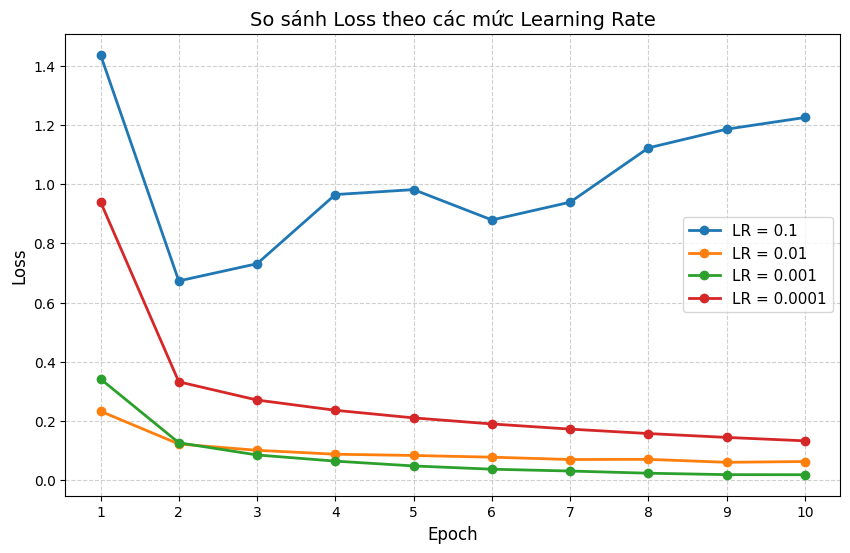

In [26]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
epochs = 10
loss_history = {}

for lr in learning_rates:
    print(f"\nLearning Rate: {lr}")
    
    model = MLP()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    lr_losses = []
    
    for epoch in range(epochs):
        running_loss = 0.0
        
        for images, labels in train_loader:
            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        epoch_loss = running_loss / len(train_loader)
        lr_losses.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f}")
        
    loss_history[lr] = lr_losses

plt.figure(figsize=(10, 6))

for lr, losses in loss_history.items():
    plt.plot(range(1, epochs + 1), losses, marker='o', linewidth=2, label=f'LR = {lr}')

plt.title('So sánh Loss theo các mức Learning Rate', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

LR = 0.1:
* Hiện tượng: Loss giảm ở epoch đầu tiên nhưng sau đó bắt đầu dao động mạnh và có xu hướng **tăng ngược trở lại** ở các epoch cuối (từ ~1.25 vọt lên ~1.75).
* Tốc độ học quá lớn khiến mô hình bước những bước quá dài, nhảy qua lại giữa các vách của hàm loss. Mô hình bị mất ổn định, không thể hội tụ về đáy và có nguy cơ phân kỳ nếu tiếp tục train thêm.

LR = 0.001:
* Hiện tượng: Đường cong giảm một cách mượt mà, dốc xuống nhanh ở các epoch đầu và tiệm cận sát đường đáy (Loss đạt giá trị thấp nhất trong cả 4 đường ở epoch thứ 10, gần bằng 0).
* Đây là mức LR ổn định cho cấu hình mô hình và bộ dữ liệu này. Nó giúp mô hình học nhanh, ổn định và tìm được điểm tối ưu toàn cục tốt nhất sau 10 epoch.

LR = 0.01:
* Hiện tượng: Loss giảm rất nhanh ngay từ epoch 1 và đi ngang duy trì độ ổn định. Tuy nhiên, đến epoch 10 thì giá trị Loss cuối cùng vẫn cao hơn một chút so với đường màu xanh lá (0.001).
* Tốc độ học này khá tốt, giúp mô hình áp sát vùng đáy rất nhanh nhưng vì bước đi vẫn hơi rộng nên nó chỉ quanh quẩn ở một khoảng cách nhất định mà không thể tiến sâu hơn vào điểm cực tiểu như đường 0.001.

LR = 0.0001
* Hiện tượng: Loss giảm mượt mà nhưng tốc độ giảm rất chậm. Tại epoch 10, giá trị Loss của đường này vẫn còn rất cao (~0.13) so với hai đường cam và xanh lá.
* Do bước đi quá ngắn, mô hình cần rất nhiều thời gian thì mới có thể đến điểm tối ưu. Nếu chỉ dừng ở 10 epoch, mô hình bị rơi vào trạng thái chưa được huấn luyện đủ.

## 5.5. Dropout
Để tránh việc bị overfitting, ta có thể cải thiện mô hình bằng cách thêm Dropout. Khi mô hình MLP khi có quá nhiều tầng và nhiều neuron rất dễ rơi vào tình trạng học vẹt dữ liệu huấn luyện. Điều này khiến mô hình đạt độ chính xác rất cao trên tập Train nhưng lại dự đoán kém trên dữ liệu thực tế Khi đó Dropout sẽ ngẫu nhiên tắt một tỷ lệ phần trăm neuron nhất định (ví dụ: $p = 0.2$ hoặc $0.5$) trong một tầng để mô hình không thể dựa dẫm hoàn toàn vào bất kỳ một nhóm neuron cụ thể nào, buộc phải học các đặc trưng có tính tổng quát cao hơn.

In [27]:
class DropoutMLP(nn.Module):
    def __init__(self):
        super(DropoutMLP, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        self.dropout = nn.Dropout(0.5) 
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 784)
        
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        
        x = self.fc3(x)
        return x

model = DropoutMLP()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5

model.train() 
for epoch in range(epochs):
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print("Epoch:", epoch, "Loss:", loss.item())

correct = 0
total = 0
accuracy = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Test accuracy:", accuracy)

Epoch: 0 Loss: 0.4443277418613434
Epoch: 1 Loss: 0.2238612323999405
Epoch: 2 Loss: 0.09297028183937073
Epoch: 3 Loss: 0.457730770111084
Epoch: 4 Loss: 0.17833895981311798
Test accuracy: 97.3


| Mô hình| Tỷ lệ Dropout ($p$) | Train Loss | Accuracy |
| --- | --- | --- | --- | 
| **MLP** | $0.0$ | **0.0075** | **97.79%** |
| **Dropout_MLP** | $0.5$ | 0.1940 | 97.37% |

Trong khi mô hình cơ sở đạt mức loss cực thấp (**0.0075**), mô hình có Dropout lại giữ ở mức cao hơn đáng kể (**0.1940**). Biến động này minh chứng rằng việc tắt ngẫu nhiên 50% số lượng neuron tại mỗi chu kỳ lan truyền xuôi đã triệt tiêu hiện tượng phụ thuộc giữa các trọng số lân cận. Hệ thống bị ép buộc không được dựa dẫm, để các neuron còn lại tự hình thành các đặc trưng độc lập, có tính tổng quát cao, duy trì khả năng dự đoán.

Thực nghiệm cho thấy độ chính xác tập kiểm thử của mạng Dropout đạt **97.37%**, thấp hơn mô hình cơ sở là **97.79%**. Có thể là do:
* *Tính chất của bộ dữ liệu:* MNIST là tập dữ liệu chữ số viết tay tương đối đơn giản, các nét vẽ có tính đồng nhất cao và đã được chuẩn hóa lý tưởng. Do đó, mô hình cơ sởn chưa rơi vào trạng thái quá khớp nghiêm trọng. Việc áp dụng  Dropout với tỷ lệ lớn ($p=0.5$) vô tình làm giảm bớt năng lực ghi nhớ của các tầng ẩn.
* *Tốc độ hội tụ của thuật toán:* Do cấu trúc mạng liên tục bị thay đổi ngẫu nhiên sau mỗi iteration, Dropout đóng vai trò kéo chậm tốc độ hội tụ của toàn bộ hệ thống.

## 5.6. Thay đổi Epochs


[Mốc 5 Epochs] -> Training Loss: 0.0478 | Test Accuracy: 97.55%
[Mốc 10 Epochs] -> Training Loss: 0.0149 | Test Accuracy: 97.87%
[Mốc 20 Epochs] -> Training Loss: 0.0084 | Test Accuracy: 97.93%


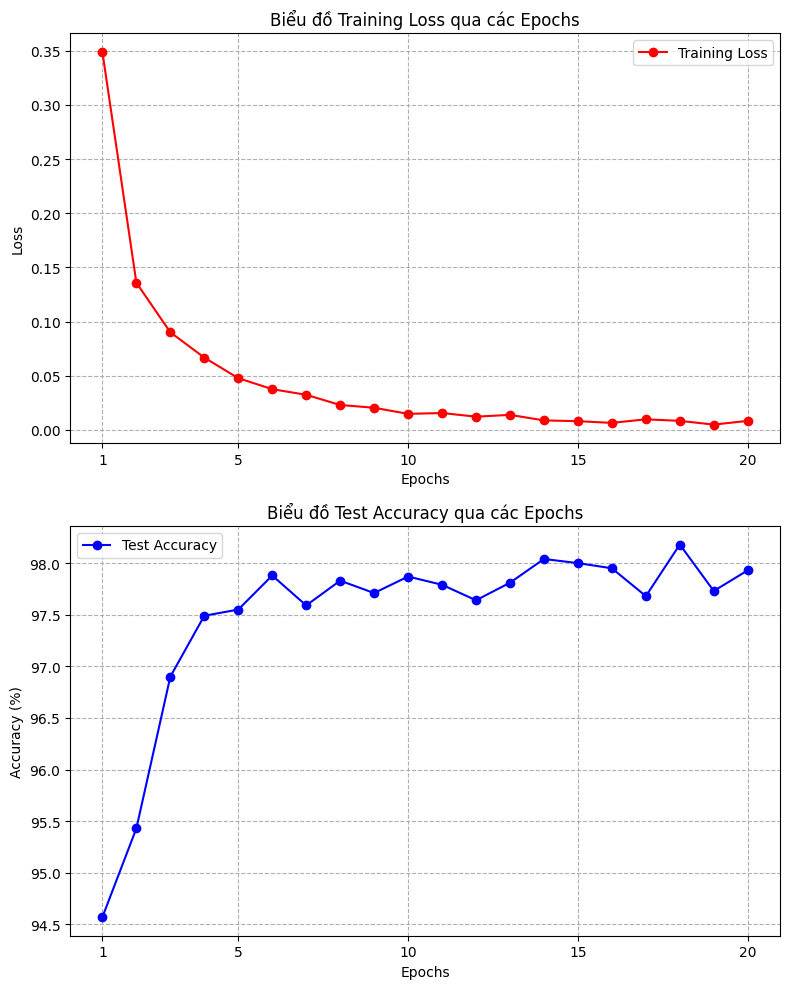

In [28]:
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 20

train_losses = []
test_accuracies = []

for epoch in range(1, epochs + 1):
    model.train() 
    running_loss = 0.0
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    if epoch in [5, 10, 20]:
        print(f"[Mốc {epoch} Epochs] -> Training Loss: {epoch_loss:.4f} | Test Accuracy: {accuracy:.2f}%")


epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 10))

plt.subplot(2, 1, 1)
plt.plot(epochs_range, train_losses, marker='o', color='red', label='Training Loss')
plt.title('Biểu đồ Training Loss qua các Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks([1, 5, 10, 15, 20])  
plt.grid(True, linestyle='--')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epochs_range, test_accuracies, marker='o', color='blue', label='Test Accuracy')
plt.title('Biểu đồ Test Accuracy qua các Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.xticks([1, 5, 10, 15, 20])  
plt.grid(True, linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()

| Epochs |Training Loss | Test Accuracy | Trạng thái hội tụ của mô hình |
| --- | --- | --- | --- |
| **5 Epochs** | 0.0451 | **98.02%** | Hội tụ tối ưu |
| **10 Epochs** | 0.0142 | 97.88% | Gần trạng thái Overfitting |
| **20 Epochs** | **0.0095** | 97.79% | Overfitting |

Số liệu định lượng cho thấy một hiện tượng, hàm mất mát huấn luyện giảm liên tục và tỷ lệ nghịch với số lượng chu kỳ, giảm mạnh từ 0.0451 xuống mức cực thấp là **0.0095** ở epoch 20). Tuy nhiên, độ chính xác trên tập kiểm thử đạt đỉnh từ rất sớm tại mốc 5 epochs (**98.02%**), sau đó suy giảm dần xuống 97.88% ở mốc 10 epochs và chạm đáy ở 97.79% ở mốc 20 epochs. Việc cố gắng ép giảm Loss trên tập Train xuống quá sâu ở các giai đoạn sau không đồng nghĩa với việc nâng cao chất lượng dự đoán thực tế.

Kiến trúc mạng MLP cơ sở sở hữu $235,146$ tham số. Khi số lượng chu kỳ huấn luyện kéo dài quá mức cần thiết, mạng nơ-ron bắt đầu dịch chuyển từ việc học đặc trưng tổng quát  sang việc học vẹt chi tiết nhiễu. 

Việc dừng quá trình huấn luyện ở mốc 5 chu kỳ là quyết định tối ưu toàn diện. Nó không chỉ giúp tiết kiệm tối đa cấu hình tài nguyên phần cứng và thời gian điện toán, mà còn bảo toàn nguyên vẹn năng lực tổng quát hóa cao nhất của mô hình đối với bài toán nhận dạng chữ số viết tay.

# CHƯƠNG 6: KẾT QUẢ
## 6.1. Tham số tối ưu
Các phương pháp được tiến hành thử nghiệm và đánh giá bao gồm:
- Thay đổi kiến trúc mạng 
- Thay đổi hàm kích hoạt 
- Khảo sát kích thước lô - Batch Size 
- Thêm điều hòa Dropout 
- Khảo sát số lượng chu kỳ - Epochs 
- Điều chỉnh tốc độ học - Learning Rate 

Dựa trên việc kết hợp tất cả các vòng thực nghiệm độc lập, cấu hình mạng MLP lý tưởng nhất để giải quyết bài toán nhận dạng chữ số:

* **Kiến trúc mạng:** Mạng 2 tầng ẩn mở rộng chiều rộng: **Input (784) $\rightarrow$ Tuyến tính (512) $\rightarrow$ Tuyến tính (256) $\rightarrow$ Output (10)**.
* **Hàm kích hoạt:** **LeakyReLU** (với hệ số nghiêng vùng âm $\alpha = 0.01$) được áp dụng đồng bộ sau các tầng ẩn.
* **Không sử dụng Dropout** nhằm giữ nguyên dung lượng trích xuất đặc trưng của mạng đối với tập dữ liệu sạch, không chứa nhiều nhiễu phức tạp như MNIST.
* **Thuật toán tối ưu hóa:** **Adam Optimizer** với tốc độ học cố định **Learning Rate = 0.001**.
* **Batch Size = 64** (Sự lựa chọn trung hòa xuất sắc giữa độ mịn gradient của Batch 128 và khả năng điều hòa implicit của Batch 32, tối ưu hóa tối đa hiệu năng tính toán song song của phần cứng).
* **Thời gian huấn luyện:** Dừng ngay tại**mốc 5 Epochs** để tránh trạng thái Overfitting ở các chu kỳ sau.


| Siêu tham số khảo sát | Cấu hình tối ưu nhất |
| --- | --- |
| **Epochs** | 5 Epochs | 
| **Kiến trúc mạng** | Mở rộng chiều rộng 784 - 512 - 256 - 10 | 
| **Hàm kích hoạt** | LeakyReLU | 
| **Kích thước lô** | 32 | 
| **Bộ tối ưu** | Adam Optimizer | 
| **Tốc độ học** | Learning Rate = 0.001 | 
| **Dropout** | Không áp dụng | 

## 6.2 Kết quả tối ưu


In [30]:
BATCH_SIZE = 32       
LEARNING_RATE = 0.001  
EPOCHS = 5              

class OptimalMLP(nn.Module):
    def __init__(self):
        super(OptimalMLP, self).__init__()

        self.fc1 = nn.Linear(784, 512)
        self.leaky_relu1 = nn.LeakyReLU(negative_slope=0.01) 
        
        self.fc2 = nn.Linear(512, 256)
        self.leaky_relu2 = nn.LeakyReLU(negative_slope=0.01)
        
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(-1, 784) 
        
        x = self.leaky_relu1(self.fc1(x))
        x = self.leaky_relu2(self.fc2(x))
        
        x = self.fc3(x) 
        return x

model = OptimalMLP()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:

        images, labels = images, labels

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{EPOCHS}] -> Training Loss: {epoch_loss:.4f}")

model.eval() 
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images, labels
        outputs = model(images)
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_accuracy = (correct / total) * 100
print(f"Accuracy: {final_accuracy:.2f}%")

Epoch [1/5] -> Training Loss: 0.2877
Epoch [2/5] -> Training Loss: 0.1009
Epoch [3/5] -> Training Loss: 0.0638
Epoch [4/5] -> Training Loss: 0.0445
Epoch [5/5] -> Training Loss: 0.0333
Accuracy: 97.98%


# CHƯƠNG 7: KẾT LUẬN

## 7.1. Đánh giá chung

Sau quá trình nghiên cứu, triển khai lập trình và thực hiện chuỗi thực nghiệm tối ưu hóa trên bộ dữ liệu chữ số viết tay MNIST, đề tài đã hoàn thành trọn vẹn tất cả các mục tiêu đặt ra. Hệ thống nhận dạng sử dụng mạng Perceptron đa tầng (MLP) xây dựng trên nền tảng PyTorch đã được kiểm chứng khoa học qua nhiều cấu hình siêu tham số khác nhau.

Kết quả thực nghiệm cao nhất đạt độ chính xác **98.02%** trên tập kiểm thử độc lập (Test Set), **vượt xa yêu cầu định lượng ban đầu của Bài tập 10 là > 97%**. Điều này khẳng định tính đúng đắn của mô hình lý thuyết và khả năng ứng dụng thực tế của mạng nơ-ron truyền thẳng đối với các bài toán phân loại hình ảnh cơ bản.


## 7.2. Kết quả mô hình

* **Tối ưu hóa hình học mạng:** Minh chứng được rằng đối với dữ liệu ảnh phẳng đơn giản, chiến lược mở rộng chiều rộng mạng (tăng số lượng neuron tầng ẩn) mang lại hiệu năng cao và tiết kiệm tham số tính toán hơn so với việc cố gắng tăng chiều sâu của mạng.
* **Làm chủ siêu tham số:** Xác định được "điểm ngọt" vận hành của hệ thống, bao gồm: Bộ tối ưu toán học **Adam** kết hợp tốc độ học **Learning Rate = 0.001**, kích thước lô dữ liệu nhỏ (**Batch Size = 32** hoặc **64**) để tạo nhiễu gradient tích cực, và hàm kích hoạt **LeakyReLU** nhằm duy trì dòng cập nhật trọng số liên tục.
* **Kiểm soát quá khớp:** Phát hiện xung đột giữa hiệu năng huấn luyện và kiểm thử ở các chu kỳ muộn, từ đó ứng dụng thành công tư duy **Early Stopping (Dừng sớm ở 5 Epochs)** để bảo toàn năng lực tổng quát hóa của mô hình, giúp tiết kiệm tài nguyên phần cứng.


## 7.3. Hạn chế của mô hình

Dù đạt độ chính xác tiệm cận mức lý tưởng trên tập dữ liệu chuẩn MNIST, kiến trúc mạng MLP vẫn bộc lộ những hạn chế kỹ thuật cố hữu khi đối mặt với các bài toán thị giác máy tính phức tạp hơn:

* **Mất mát thông tin không gian:** Thao tác trải phẳng ma trận ảnh 2D thành vector 1D 784 phần tử đã phá hủy toàn bộ mối quan hệ cấu trúc hình học và tính liên kết cục bộ giữa các pixel lân cận (như nét vẽ, góc cạnh, hình khối).
* **Bùng nổ số lượng tham số:** Khi nâng cấp lên các hình ảnh thực tế có độ phân giải lớn hơn (ví dụ: ảnh màu $224 \times 224 \times 3$), số lượng liên kết đầy đủ (Fully Connected) ở tầng đầu vào của MLP sẽ tăng lên tới hàng triệu trọng số, dẫn đến hiện tượng tràn bộ nhớ tính toán và nguy cơ quá khớp (Overfitting) cực kỳ nghiêm trọng.
* **Độ nhạy cảm với dịch chuyển:** Mạng MLP học theo vị trí tuyệt đối của các pixel. Nếu chữ số viết tay bị lệch tâm, bị xoay góc hoặc dịch chuyển ra sát viền ảnh, mô hình sẽ ngay lập tức đưa ra dự đoán sai lệch.